# Interpolating Hydrographs Under Parameter Uncertainty

A few years ago, I watched a YouTube video about a hydrological model that allowed users to define uncertainty ranges for model parameters. The model likely generated multiple runoff curves from a $2^n$ experimental design. Afterwards, sliders could be used to explore how each parameter influenced the discharge hydrograph.

What fascinated me was that the displayed curve appeared instantly, without rerunning the full model each time. I have been curious about that idea ever since, so this notebook is my attempt to experiment with and better understand that workflow.

## Wasserstein Barycenter

A Wasserstein barycenter is an “average” of several distributions or curves that respects their shape and location. Instead of averaging point-by-point values, it transports mass in an optimal way and then computes a central compromise. This often gives a more realistic intermediate curve when peaks are shifted in time or space.

As a first step, we test the idea with the PDF and CDF of normal distributions. A key takeaway is that one must be careful whether a curve is a CDF or a PDF when computing Wasserstein barycenters, because this distinction directly affects the interpretation and the result.

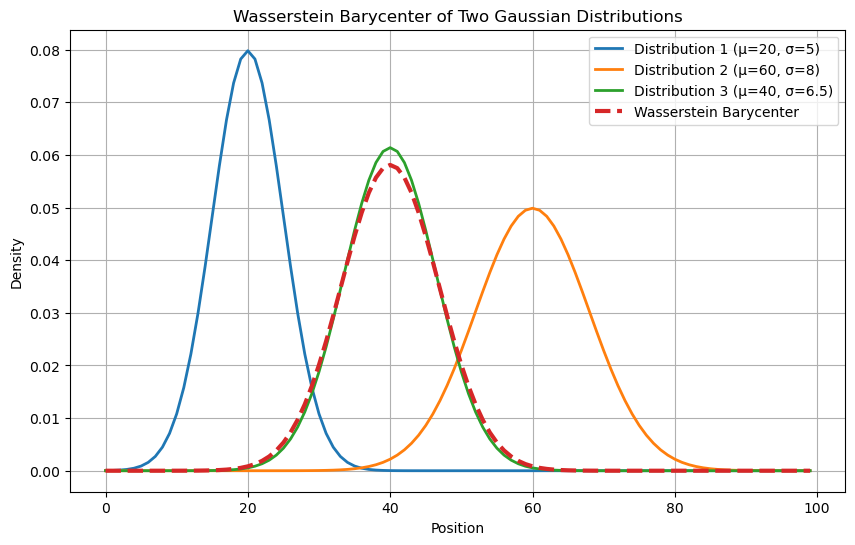

In [1]:
#%pip install POT

import numpy as np
import matplotlib.pyplot as plt
import ot # POT

# Generate two 1D Gaussian distributions
n = 100  # Number of discretization points
x = np.arange(n)  # Positions of the points

# Create Gaussian distributions with different means
a1 = ot.datasets.make_1D_gauss(n, m=20, s=5)  # Mean 20, std 5
a2 = ot.datasets.make_1D_gauss(n, m=60, s=8)  # Mean 60, std 8
a3 = ot.datasets.make_1D_gauss(n, m=0.5*(20+60), s=0.5*(8+5))  # Mean 40, std 6.5

# Create cost matrix (squared distance)
M = ot.utils.dist0(n)
M /= M.max()  # Normalization

# Compute Wasserstein barycenter with Sinkhorn
# This example treats the curves as mass/density-like vectors on the x-grid.
reg = 1e-3  # Regularization parameter
weights = [0.5, 0.5]  # Equal weighting of both distributions

barycenter = ot.bregman.barycenter(
    np.vstack((a1, a2)).T,
    M,
    reg,
    weights=weights,
    method='sinkhorn'
)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(x, a1, label='Distribution 1 (μ=20, σ=5)', linewidth=2)
plt.plot(x, a2, label='Distribution 2 (μ=60, σ=8)', linewidth=2)
plt.plot(x, a3, label='Distribution 3 (μ=40, σ=6.5)', linewidth=2)
plt.plot(x, barycenter, '--', label='Wasserstein Barycenter', linewidth=3)
plt.title('Wasserstein Barycenter of Two Gaussian Distributions')
plt.xlabel('Position')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


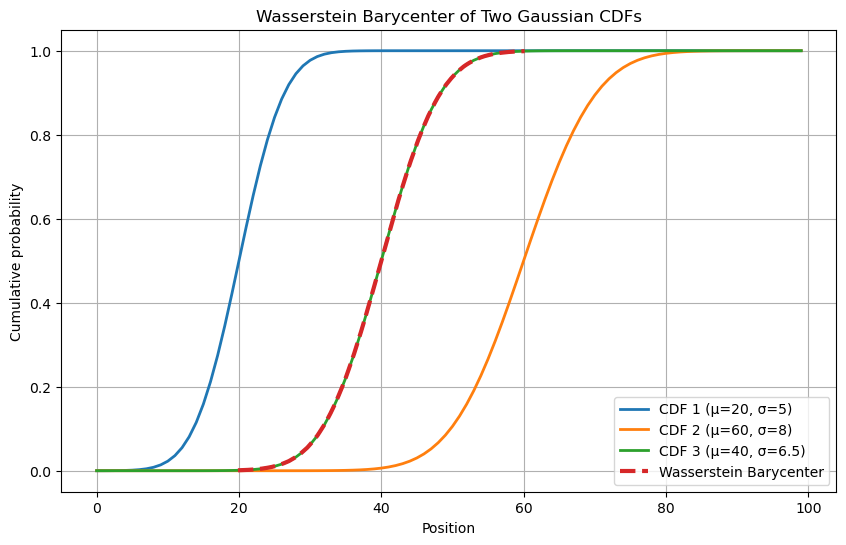

In [2]:
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

# Create Gaussian distributions with different means
a1 = norm.cdf(x, loc=20, scale=5)  # Mean 20, std 5
a2 = norm.cdf(x, loc=60, scale=8)  # Mean 60, std 8
a3 = norm.cdf(x, loc=0.5*(20+60), scale=0.5*(8+5))  # Mean 40, std 6.5

def wasserstein_cdf_average(x1, y1, x2, y2, weight=0.5):
    """
    Computes the Wasserstein barycenter (average) of two CDFs
    based on discrete x/y points.
    """
    # This example works in CDF/quantile space, not as a PDF/mass-vector barycenter.

    # 1. Create quantile functions (y -> x interpolation)
    # Using 'linear' interpolation, extrapolating outside [0, 1].
    inv_cdf1 = interp1d(y1, x1, kind='linear', fill_value="extrapolate")
    inv_cdf2 = interp1d(y2, x2, kind='linear', fill_value="extrapolate")
    
    # 2. Define a common probability grid (p)
    p_grid = np.linspace(0.001, 0.999, 1000)
    
    # 3. Average the quantiles (this is the core of the Wasserstein barycenter)
    x_barycenter = (1 - weight) * inv_cdf1(p_grid) + weight * inv_cdf2(p_grid)
    
    # x_barycenter are the x-values, p_grid the corresponding probabilities
    return x_barycenter, p_grid

xb, barycenter = wasserstein_cdf_average(x, a1, x, a2, weight=0.5)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(x, a1, label='CDF 1 (μ=20, σ=5)', linewidth=2)
plt.plot(x, a2, label='CDF 2 (μ=60, σ=8)', linewidth=2)
plt.plot(x, a3, label='CDF 3 (μ=40, σ=6.5)', linewidth=2)
plt.plot(xb, barycenter, '--', label='Wasserstein Barycenter', linewidth=3)
plt.title('Wasserstein Barycenter of Two Gaussian CDFs')
plt.xlabel('Position')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(True)
plt.show()


## Storage cascade

A storage cascade is a simple rainfall-runoff concept where water passes through several connected storage units one after another. Each unit delays and smooths the flow, so short, sharp rainfall pulses become broader and slower runoff curves.

With this, one can model the runoff response of catchment areas.

In this notebook, the storage cascade is used as a dummy for a more complex hydrological model.


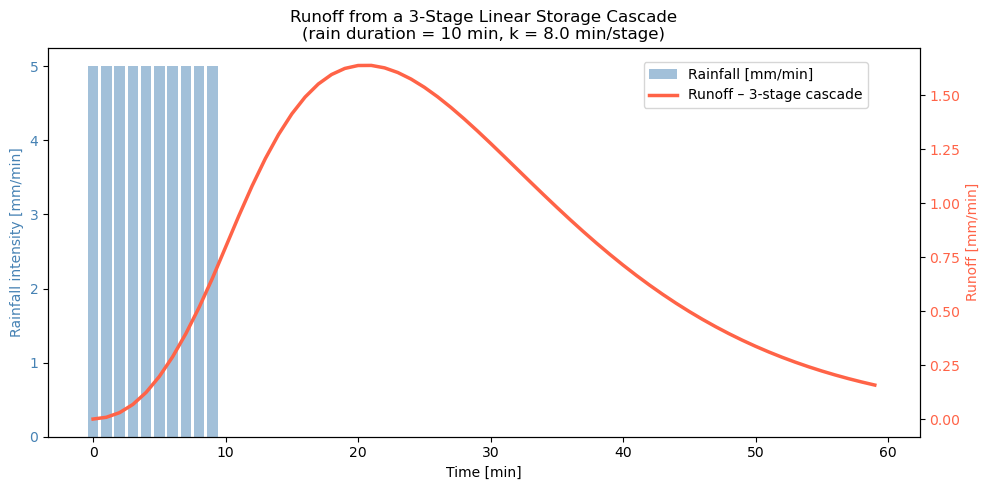

Peak runoff: 1.639 mm/min at t = 21 min
Total runoff volume: 48.39 mm  |  Total rainfall: 50.00 mm


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def storage_cascade(rainfall_mm_per_min, dt_min, k_min, n_stages=3):
    """
    Simulates runoff from a linear storage cascade (Nash cascade).

    Parameters
    ----------
    rainfall_mm_per_min : array-like
        Rainfall intensity time series [mm/min] at each time step.
    dt_min : float
        Time step size [minutes].
    k_min : float
        Retention constant of each reservoir [minutes].
    n_stages : int
        Number of cascade stages (default: 3).

    Returns
    -------
    t : np.ndarray
        Time axis [minutes].
    Q : np.ndarray
        Outflow from the last reservoir [mm/min].
    """
    rainfall = np.asarray(rainfall_mm_per_min, dtype=float)
    n_steps = len(rainfall)
    t = np.arange(n_steps) * dt_min

    # Exact solution for linear reservoir: Q_out(t+dt) = Q_in + (Q_out(t) - Q_in) * exp(-dt/k)
    alpha = np.exp(-dt_min / k_min)

    # State array: outflow of each stage
    Q_stages = np.zeros((n_steps, n_stages))

    for i in range(1, n_steps):
        Q_in = rainfall[i - 1]           # inflow to first stage
        for s in range(n_stages):
            Q_prev = Q_stages[i - 1, s]
            Q_stages[i, s] = Q_in + (Q_prev - Q_in) * alpha
            Q_in = Q_stages[i, s]        # outflow becomes inflow to next stage

    Q_out = Q_stages[:, -1]
    return t, Q_out


# --- Example: 10-minute rain event ---
dt = 1.0           # time step [min]
total_time = 60    # simulation duration [min]
rain_duration = 10 # rain duration [min]
k = 8.0            # retention constant per stage [min]

# Rainfall time series: constant intensity for 10 minutes, then 0
intensity = 5.0    # mm/min during rain
n_steps = int(total_time / dt)
rainfall = np.where(np.arange(n_steps) * dt < rain_duration, intensity, 0.0)

t, Q = storage_cascade(rainfall, dt_min=dt, k_min=k, n_stages=3)

# Visualization
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(t, rainfall, width=dt * 0.8, color='steelblue', alpha=0.5, label='Rainfall [mm/min]')
ax1.set_ylabel('Rainfall intensity [mm/min]', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(t, Q, color='tomato', linewidth=2.5, label='Runoff – 3-stage cascade')
ax2.set_ylabel('Runoff [mm/min]', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_xlabel('Time [min]')
plt.title(f'Runoff from a 3-Stage Linear Storage Cascade\n'
          f'(rain duration = {rain_duration} min, k = {k} min/stage)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

print(f"Peak runoff: {Q.max():.3f} mm/min at t = {t[Q.argmax()]:.0f} min")
print(f"Total runoff volume: {Q.sum() * dt:.2f} mm  |  Total rainfall: {rainfall.sum() * dt:.2f} mm")


## Barycenter with Storage Cascade

In this section, we combine two runoff curves from the storage cascade (different $k_{min}$ values) and compute an unbalanced Wasserstein barycenter. The result is an interpolated hydrograph that approximates a physically plausible intermediate response.

This demonstrates the key idea behind fast interactive exploration: instead of rerunning a full model for every slider change, one can approximate intermediate hydrographs from a small set of precomputed simulations.

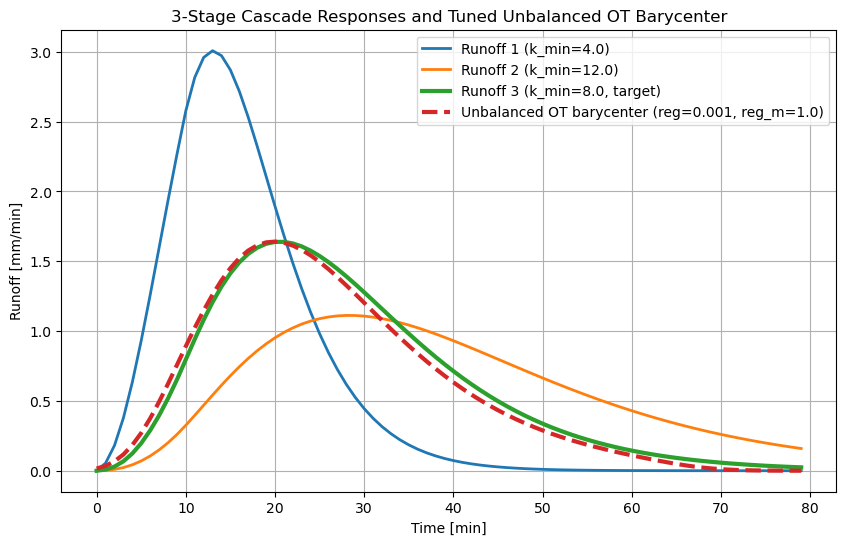

Best reg: 0.001
Best reg_m: 1.0
Mean absolute error (q3 vs tuned barycenter): 0.05170 mm/min
RMSE (q3 vs tuned barycenter): 0.05696 mm/min


In [4]:
# Example: Different k_min values in storage_cascade and unbalanced OT barycenter
# with automatic tuning of reg and reg_m

# Common rainfall forcing
rain_duration = 10.0   # minutes
sim_duration = 80.0    # minutes
dt = 1.0               # minutes
intensity = 5.0        # mm/min

n_steps = int(sim_duration / dt)
time = np.arange(n_steps) * dt
rainfall = np.where(time < rain_duration, intensity, 0.0)

# Three cascade responses with different retention constants
k1 = 4.0
k2 = 12.0
k3 = 8.0  # target curve (between k1 and k2)

t1, q1 = storage_cascade(rainfall, dt_min=dt, k_min=k1, n_stages=3)
t2, q2 = storage_cascade(rainfall, dt_min=dt, k_min=k2, n_stages=3)
t3, q3 = storage_cascade(rainfall, dt_min=dt, k_min=k3, n_stages=3)

# Build OT cost matrix on the time grid
M_time = ot.utils.dist0(len(time))
M_time /= M_time.max()

# Input matrix for barycenter: columns are the two source curves
A = np.vstack((q1, q2)).T
weights = [0.5, 0.5]

# Tune reg and reg_m to best match q3
reg_candidates = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
reg_m_candidates = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]

best_rmse = np.inf
best_reg = None
best_reg_m = None
best_bary = None

for reg_test in reg_candidates:
    for reg_m_test in reg_m_candidates:
        q_test = ot.unbalanced.barycenter_unbalanced(
            A,
            M_time,
            reg_test,
            reg_m_test,
            weights=weights,
            method='sinkhorn'
        )
        rmse_test = np.sqrt(np.mean((q3 - q_test) ** 2))
        if rmse_test < best_rmse:
            best_rmse = rmse_test
            best_reg = reg_test
            best_reg_m = reg_m_test
            best_bary = q_test

q_bary_unbalanced = best_bary

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(t1, q1, label=f'Runoff 1 (k_min={k1})', linewidth=2)
plt.plot(t2, q2, label=f'Runoff 2 (k_min={k2})', linewidth=2)
plt.plot(t3, q3, label=f'Runoff 3 (k_min={k3}, target)', linewidth=3)
plt.plot(
    time,
    q_bary_unbalanced,
    '--',
    label=f'Unbalanced OT barycenter (reg={best_reg}, reg_m={best_reg_m})',
    linewidth=3
)
plt.title('3-Stage Cascade Responses and Tuned Unbalanced OT Barycenter')
plt.xlabel('Time [min]')
plt.ylabel('Runoff [mm/min]')
plt.legend()
plt.grid(True)
plt.show()

# Quantify similarity between target and tuned barycenter
l1_error = np.mean(np.abs(q3 - q_bary_unbalanced))
rmse = np.sqrt(np.mean((q3 - q_bary_unbalanced) ** 2))
print(f"Best reg: {best_reg}")
print(f"Best reg_m: {best_reg_m}")
print(f"Mean absolute error (q3 vs tuned barycenter): {l1_error:.5f} mm/min")
print(f"RMSE (q3 vs tuned barycenter): {rmse:.5f} mm/min")


## Conclusion

This notebook shows how Wasserstein barycenters can be used to interpolate between runoff curves in a way that respects timing and shape better than simple pointwise averaging.

Using a storage cascade as a lightweight proxy model, we reproduced the core concept of uncertainty exploration with fast curve updates. This can be a useful building block for interactive hydrological tools where responsiveness and interpretability are both important.
